# Análisis del Corpus Sintético de Biografías

Este notebook verifica la calidad y diversidad del corpus generado antes de usarlo para entrenar embeddings.

In [2]:
import sys
sys.path.insert(0, '..')  # para importar src/

import json
import sqlite3
import random
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
DB_PATH = Path('../data/synthetic/corpus.db')

## 1. Carga del corpus

In [3]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

df = pd.read_sql_query("""
    SELECT gb.id, gb.username, gb.age, gb.bio, gb.bio_length, gb.model,
           gb.template_id, gb.temperature, gb.attempts, gb.is_duplicate,
           p.career, p.year, p.personality, p.interests, p.origin, p.writing_style
    FROM generated_bios gb
    JOIN personas p ON p.id = gb.persona_id
    WHERE gb.is_valid = 1
""", conn)

df_valid = df[df['is_duplicate'] == 0].copy()
print(f"Total bios en BD:       {len(df)}")
print(f"Bios válidas (sin dup): {len(df_valid)}")
print(f"Duplicados marcados:    {df['is_duplicate'].sum()}")
df_valid.head(3)

Total bios en BD:       20
Bios válidas (sin dup): 20
Duplicados marcados:    0


,id,username,age,bio,bio_length,model,template_id,temperature,attempts,is_duplicate,career,year,personality,interests,origin,writing_style
0,1,tizianobenjamin,21,"Estudiante de Comunicación Social, apasionado ...",130,qwen2.5:14b,1,0.95,1,0,Comunicación Social,4,creativo y curioso,"[""podcasts"", ""vóley"", ""pintura""]",Córdoba capital,formal y conciso
1,2,santiagobenjami,21,"Amante de la arq y la impresión 3D, me vuelvo ...",142,qwen2.5:14b,8,0.80,1,0,Arquitectura,4,ambicioso y enfocado,"[""3D printing"", ""jazz"", ""natación"", ""emprendim...",Rosario,"muy coloquial, estilo texto de WhatsApp"
2,3,solvillalba58,19,Estudio biología pero me apasiona la robótica ...,150,qwen2.5:14b,3,0.70,1,0,Biología,2,empático y colaborativo,"[""tenis"", ""robótica"", ""tocar guitarra"", ""polít...",Mar del Plata,con algunos emojis


## 2. Distribuciones

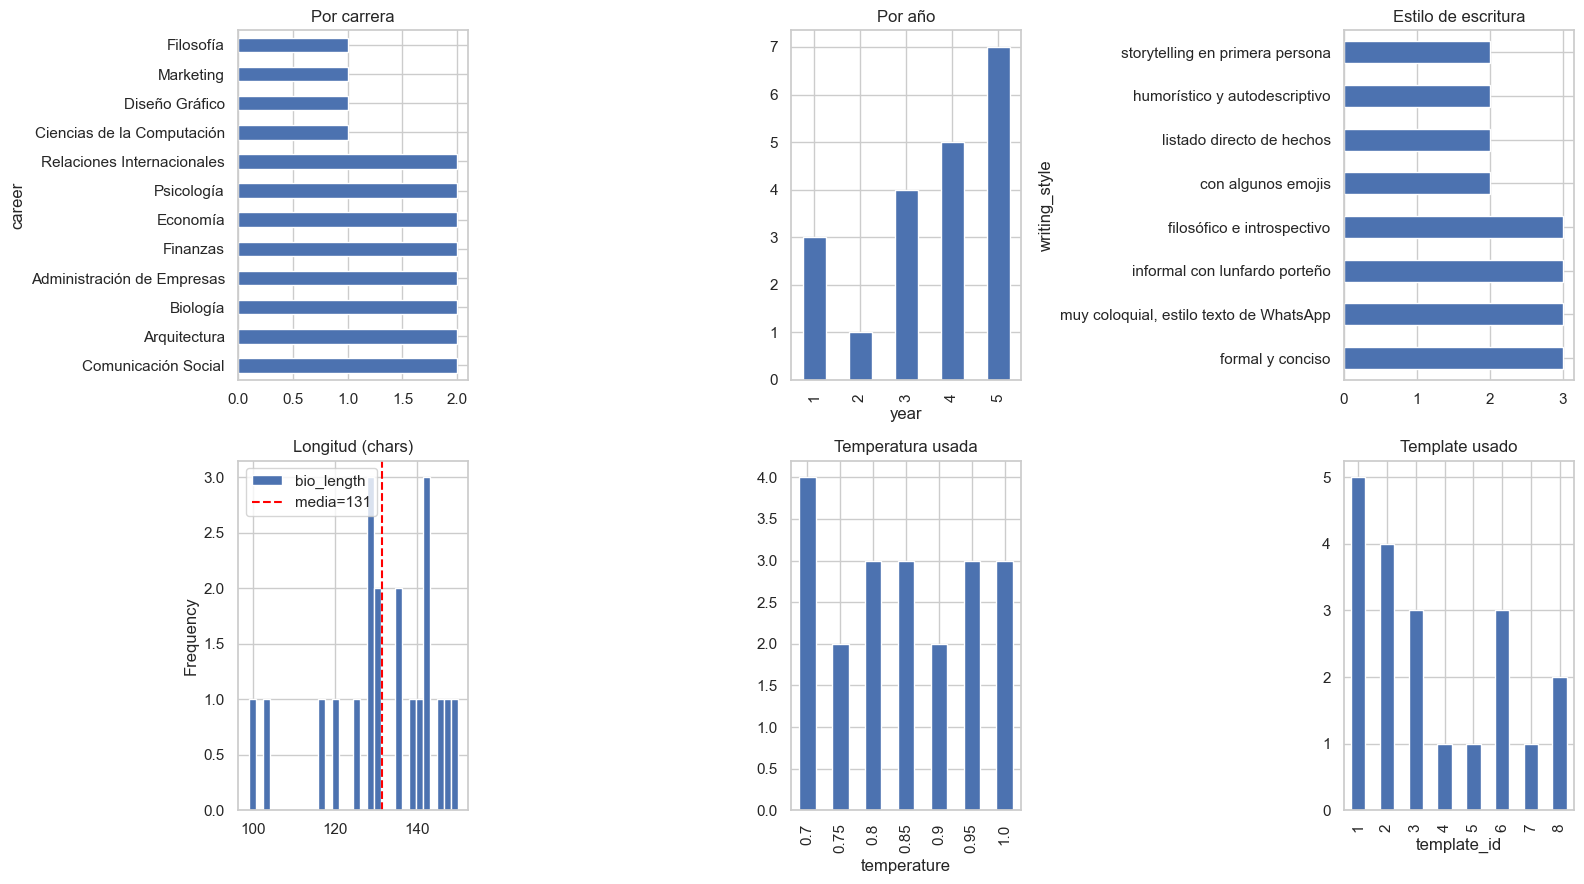

Longitud media: 131.4 | min: 99 | max: 150


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Carrera
df_valid['career'].value_counts().plot.barh(ax=axes[0,0], title='Por carrera')

# Año
df_valid['year'].value_counts().sort_index().plot.bar(ax=axes[0,1], title='Por año')

# Estilo de escritura
df_valid['writing_style'].value_counts().plot.barh(ax=axes[0,2], title='Estilo de escritura')

# Longitud de bio
df_valid['bio_length'].plot.hist(bins=30, ax=axes[1,0], title='Longitud (chars)')
axes[1,0].axvline(df_valid['bio_length'].mean(), color='red', linestyle='--', label=f"media={df_valid['bio_length'].mean():.0f}")
axes[1,0].legend()

# Temperatura
df_valid['temperature'].value_counts().sort_index().plot.bar(ax=axes[1,1], title='Temperatura usada')

# Template
df_valid['template_id'].value_counts().sort_index().plot.bar(ax=axes[1,2], title='Template usado')

plt.tight_layout()
plt.savefig('../data/synthetic/distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Longitud media: {df_valid['bio_length'].mean():.1f} | min: {df_valid['bio_length'].min()} | max: {df_valid['bio_length'].max()}")

## 3. Diversity score (vocabulario único)

Total tokens:   454
Unique tokens:  259
Diversity score (unique/total): 0.570  (objetivo > 0.40)


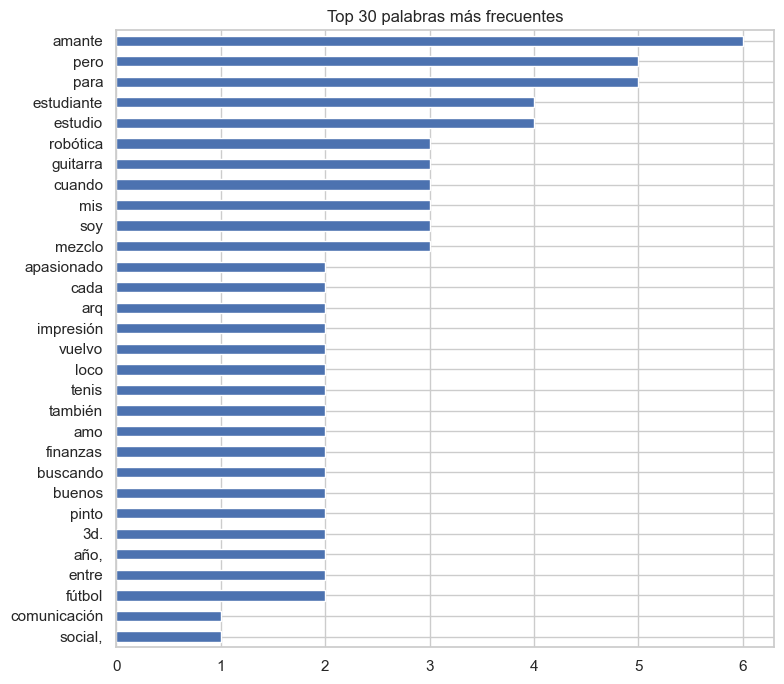

  'amante': aparece en 30.0% de las bios — ⚠️ REVISAR TEMPLATES
  'pero': aparece en 25.0% de las bios — ⚠️ REVISAR TEMPLATES
  'para': aparece en 25.0% de las bios — ⚠️ REVISAR TEMPLATES
  'estudiante': aparece en 20.0% de las bios — ok
  'estudio': aparece en 20.0% de las bios — ok
  'robótica': aparece en 15.0% de las bios — ok
  'guitarra': aparece en 15.0% de las bios — ok
  'cuando': aparece en 20.0% de las bios — ok
  'mis': aparece en 15.0% de las bios — ok
  'soy': aparece en 15.0% de las bios — ok


In [5]:
all_tokens = ' '.join(df_valid['bio'].tolist()).lower().split()
unique_tokens = set(all_tokens)

diversity_score = len(unique_tokens) / len(all_tokens)
print(f"Total tokens:   {len(all_tokens):,}")
print(f"Unique tokens:  {len(unique_tokens):,}")
print(f"Diversity score (unique/total): {diversity_score:.3f}  (objetivo > 0.40)")

# Top 30 palabras más frecuentes
from collections import Counter
STOPWORDS = {'de', 'la', 'el', 'en', 'y', 'a', 'que', 'me', 'un', 'una', 'los', 'las', 'mi', 'con', 'del', 'por', 'es', 'lo', 'se'}
word_freq = Counter(t for t in all_tokens if t not in STOPWORDS and len(t) > 2)
top30 = pd.Series(dict(word_freq.most_common(30)))

top30.plot.barh(figsize=(8, 7), title='Top 30 palabras más frecuentes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Alerta si alguna palabra aparece en más del 20% de las bios
ALERT_THRESHOLD = 0.20
for word, count in word_freq.most_common(10):
    pct = df_valid['bio'].str.lower().str.contains(word).mean()
    flag = '⚠️ REVISAR TEMPLATES' if pct > ALERT_THRESHOLD else 'ok'
    print(f"  '{word}': aparece en {pct:.1%} de las bios — {flag}")

## 4. Similitud semántica (muestra de 200 bios)

In [6]:
from sentence_transformers import SentenceTransformer

SAMPLE_N = 200
sample = df_valid.sample(min(SAMPLE_N, len(df_valid)), random_state=42)
bios_sample = sample['bio'].tolist()

print(f"Calculando embeddings para {len(bios_sample)} bios...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embs = model.encode(bios_sample, normalize_embeddings=True, show_progress_bar=True)
embs = np.array(embs, dtype=np.float32)

sim_matrix = embs @ embs.T
mask = np.ones(sim_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
off_diag = sim_matrix[mask]

print(f"\nSimilitud media entre pares:         {off_diag.mean():.3f}  (objetivo < 0.50)")
print(f"Similitud máxima (peor caso):        {off_diag.max():.3f}")
print(f"Percentil 95:                        {np.percentile(off_diag, 95):.3f}")
print(f"Pares con similitud > 0.85:          {(off_diag >= 0.85).mean()*100:.1f}%  (objetivo < 5%)")

# Heatmap de similitud
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    sim_matrix[:50, :50],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    ax=ax,
    xticklabels=False,
    yticklabels=False,
)
ax.set_title('Similitud coseno — primeras 50 bios de la muestra\n(Verde=distinto, Rojo=similar)')
plt.tight_layout()
plt.savefig('../data/synthetic/similarity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'sentence_transformers'

## 5. Spot-check: 20 bios aleatorias

In [7]:
spot = df_valid.sample(20, random_state=7)
for _, row in spot.iterrows():
    print(f"[{row['career'][:20]:<20} | {row['writing_style'][:20]:<20} | {row['bio_length']:>3}c]")
    print(f"  {row['bio']}")
    print()

[Arquitectura         | muy coloquial, estil | 142c]
  Amante de la arq y la impresión 3D, me vuelvo loco con el jazz los fines de semana. Nadador empedernido y soñando con mi propio estudio en BA.

[Finanzas             | storytelling en prim | 142c]
  Soy Lupe, estudiante de Finanzas con sueños de escenario. Programo apps y actúo en mi tiempo libre, entre Buenos Aires y mis raíces rosarinas.

[Biología             | con algunos emojis   | 150c]
  Estudio biología pero me apasiona la robótica y el tenis 🎾🤖 Guitarra incluida 🎸 Activista estudiantil en ciernes ✊ Empatía de sobra para colaborar 🤝 D

[Administración de Em | listado directo de h | 103c]
  Estudio administración, amo viajes, recitales e IA. Pinto de vez en cuando. Competitivo por naturaleza.

[Comunicación Social  | humorístico y autode | 135c]
  Música, cafe y algoritmos porfavor. Jugón de paddle y guitarrero nocturno. Analítico obsesivo, pero con un toque cariñoso para la vida.

[Comunicación Social  | formal y conciso   

## 6. Pares más similares (near-duplicates restantes)

In [ ]:
# Mostrar los 10 pares de bios más similares de la muestra
indices = np.triu_indices(len(bios_sample), k=1)
pairs = list(zip(indices[0], indices[1], sim_matrix[indices]))
pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 10 pares más similares:")
for i, j, score in pairs[:10]:
    print(f"  Similitud: {score:.3f}")
    print(f"    A: {bios_sample[i]}")
    print(f"    B: {bios_sample[j]}")
    print()